## Chapter 2 of *lme4: Mixed-effects modeling with R* (2022)

In [1]:
from hea import data
from hea.R import *
from hea.plot import *
from hea.models import lme


### 2.1.1

In [2]:
penicillin = data("Penicillin", "lme4")
summary(penicillin)

  diameter        plate     sample
Min.   :18.00  a      :  6  A:24
1st Qu.:22.00  b      :  6  B:24
Median :23.00  c      :  6  C:24
Mean   :22.97  d      :  6  D:24
3rd Qu.:24.00  e      :  6  E:24
Max.   :27.00  f      :  6  F:24
               (Other):108

### 2.1.2

In [3]:
fm03 = lme('diameter ~ 1 + (1 | plate) + (1 | sample)', penicillin)
summary(fm03)

Linear mixed model fit by REML
Formula: diameter ~ 1 + (1 | plate) + (1 | sample)

REML criterion at convergence: 330.8606

Scaled residuals:
    Min      1Q Median     3Q    Max
-2.0794 -0.6714 0.0629 0.5838 2.9798

Random effects:
 Groups   Name        Variance Std.Dev.
 plate    (Intercept) 0.7172   0.8468
 sample   (Intercept) 3.7359   1.9328
 Residual             0.3024   0.5499
Number of obs: 144, groups:  plate, 24; sample, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   22.9722      0.8091    28.39


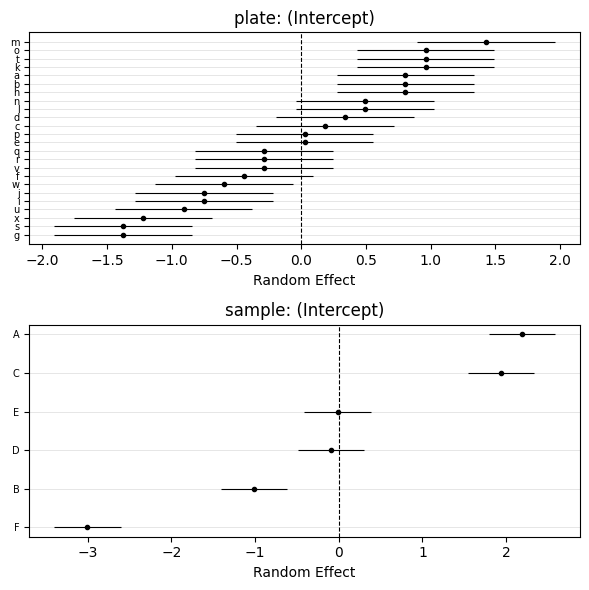

In [4]:
_ = fm03.plot_ranef(layout="vertical", figsize=(6, 6))

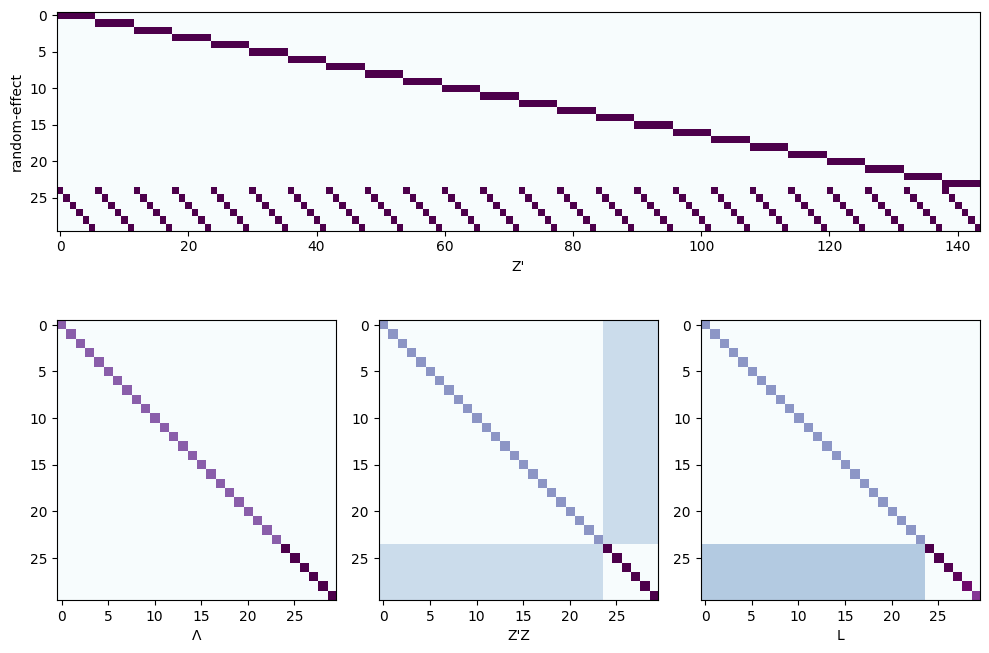

In [5]:
_ = fm03.plot_design()

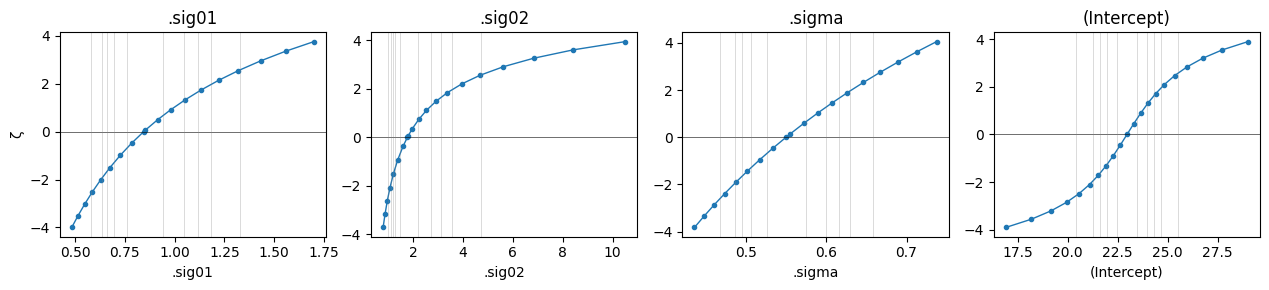

In [6]:
pr03 = fm03.profile()
_ = pr03.plot()

In [7]:
confint(pr03)

parameter,2.5%,97.5%
str,f64,f64
""".sig01""",0.633566,1.182103
""".sig02""",1.095784,3.556271
""".sigma""",0.485845,0.629453
"""(Intercept)""",21.266593,24.677852


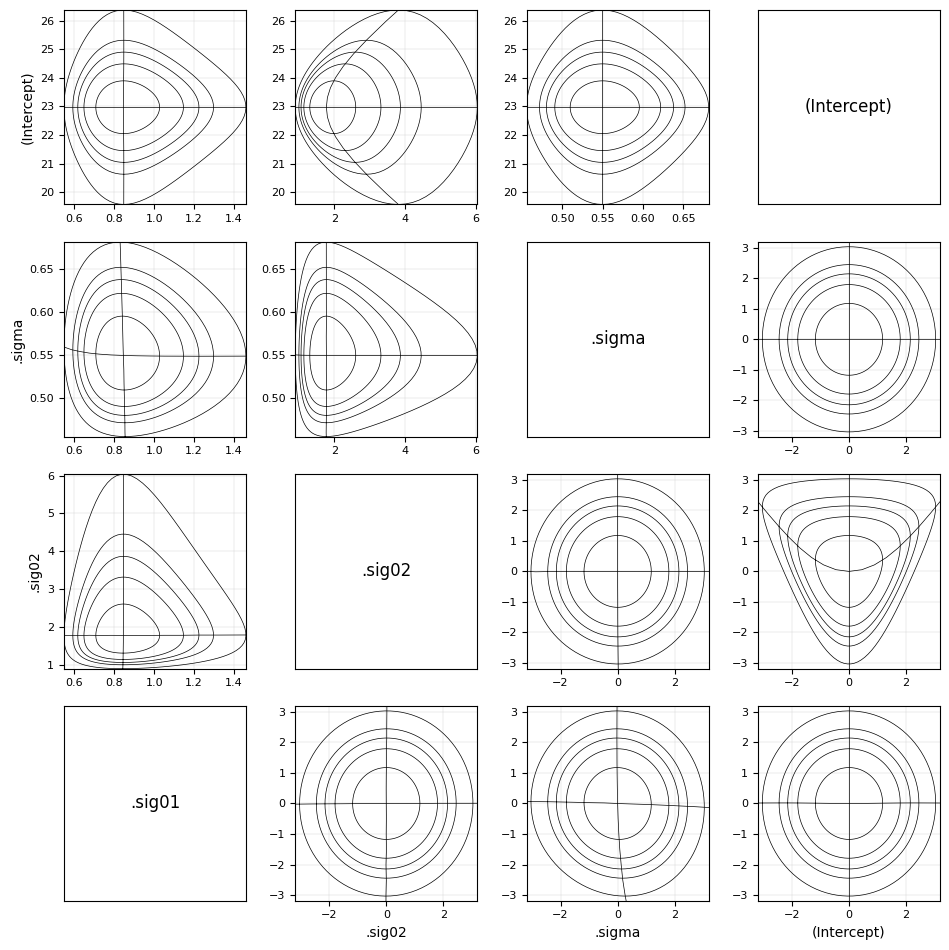

In [8]:
_ = pr03.plot_pairs()

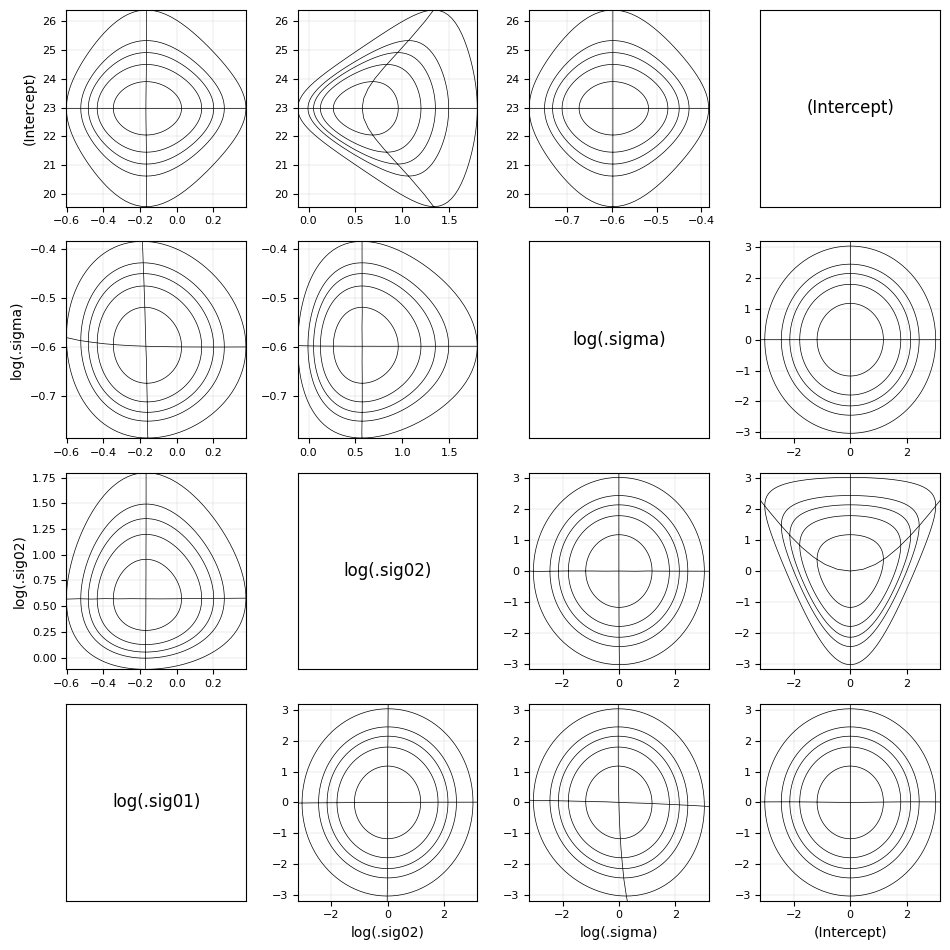

In [9]:
_ = pr03.plot_pairs(transform="log")

### 2.2.1

In [10]:
pastes = data("Pastes", "lme4")
summary(pastes)

  strength       batch     cask    sample
Min.   :54.20  A      : 6  a:20  A:a    : 2
1st Qu.:57.50  B      : 6  b:20  A:b    : 2
Median :59.30  C      : 6  c:20  A:c    : 2
Mean   :60.05  D      : 6        B:a    : 2
3rd Qu.:62.88  E      : 6        B:b    : 2
Max.   :66.00  F      : 6        B:c    : 2
               (Other):24        (Other):48

### 2.2.2

In [11]:
summary(fm04 := lme('strength ~ 1 + (1 | sample) + (1 | batch)', pastes, REML=False))

Linear mixed model fit by maximum likelihood
Formula: strength ~ 1 + (1 | sample) + (1 | batch)

     AIC      BIC    logLik -2*log(L) df.resid
255.9945 264.3718 -123.9972  247.9945       56

Scaled residuals:
    Min      1Q Median     3Q    Max
-1.4847 -0.5263 0.0122 0.4674 1.3892

Random effects:
 Groups   Name        Variance Std.Dev.
 sample   (Intercept) 8.436    2.9045
 batch    (Intercept) 1.197    1.0939
 Residual             0.678    0.8234
Number of obs: 60, groups:  sample, 30; batch, 10

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   60.0533      0.6420    93.54


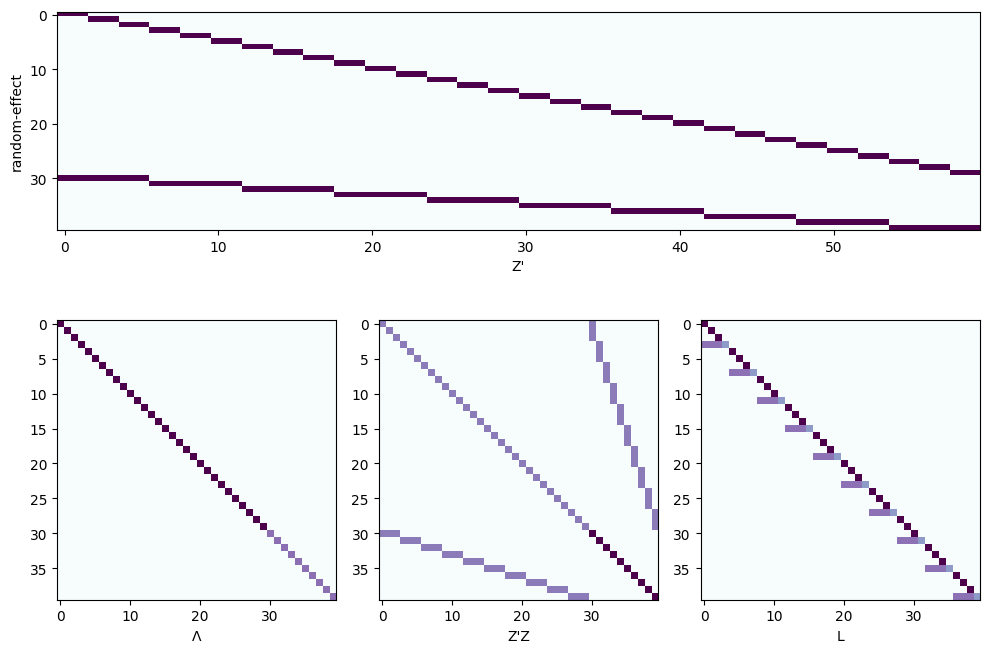

In [12]:
_ = fm04.plot_design()

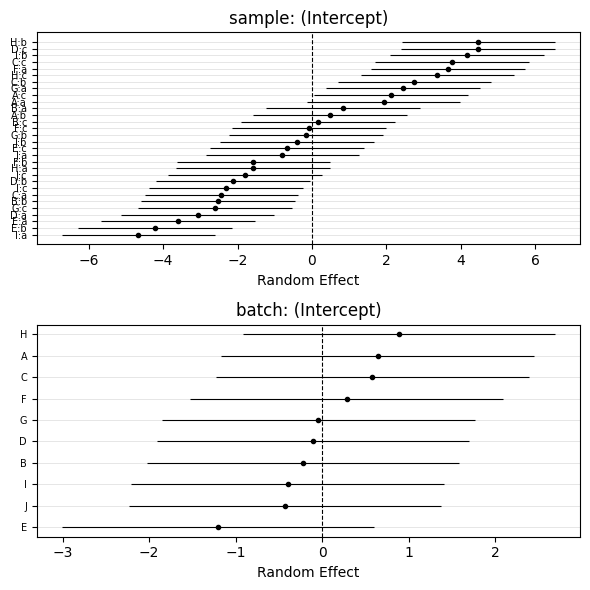

In [13]:
_ = fm04.plot_ranef(layout="vertical", figsize=(6, 6))

### 2.2.3

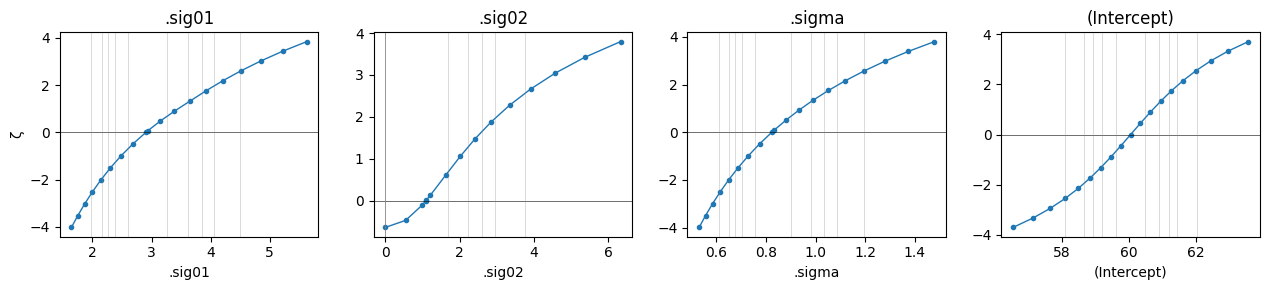

In [14]:
pr04 = fm04.profile()
_ = pr04.plot()

### 2.2.4

In [15]:
fm04a = lme('strength ~ 1 + (1 | sample)', pastes, REML=False)
summary(fm04a)

Linear mixed model fit by maximum likelihood
Formula: strength ~ 1 + (1 | sample)

     AIC      BIC    logLik -2*log(L) df.resid
254.4017 260.6847 -124.2009  248.4017       57

Scaled residuals:
    Min      1Q Median     3Q    Max
-1.4919 -0.5415 0.0150 0.4621 1.3884

Random effects:
 Groups   Name        Variance Std.Dev.
 sample   (Intercept) 9.6355   3.1041
 Residual             0.6778   0.8233
Number of obs: 60, groups:  sample, 30

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   60.0533      0.5766    104.1


In [16]:
from hea.R import anova
anova(fm04a, fm04)

Analysis of Variance Table (likelihood ratio test)

fm04a: strength ~ 1 + (1 | sample)
fm04: strength ~ 1 + (1 | sample) + (1 | batch)

       npar       AIC       BIC     logLik  -2*log(L)   Chisq  Df  Pr(>Chisq)
fm04a     3  254.4017  260.6847  -124.2009   248.4017
fm04      4  255.9945  264.3718  -123.9972   247.9945  0.4072   1      0.5234
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


### 2.2.5

In [17]:
confint(pr04)

parameter,2.5%,97.5%
str,f64,f64
""".sig01""",2.157932,4.053583
""".sig02""",0.0,2.946576
""".sigma""",0.652028,1.085448
"""(Intercept)""",58.663633,61.443034


In [18]:
pr04a = fm04a.profile()
confint(pr04a)

parameter,2.5%,97.5%
str,f64,f64
""".sig01""",2.430638,4.122009
""".sigma""",0.65202,1.085448
"""(Intercept)""",58.886182,61.220485


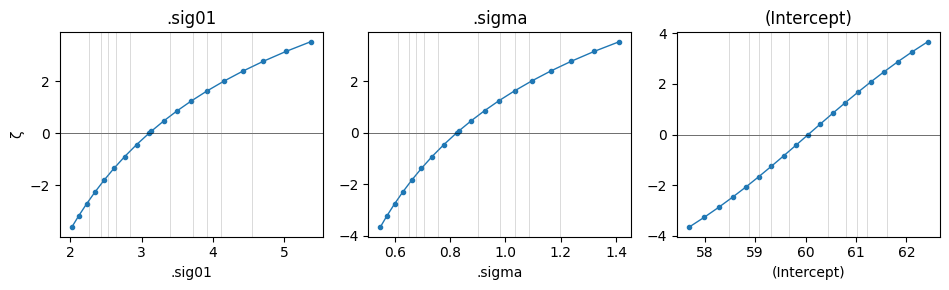

In [19]:
_ = pr04a.plot()

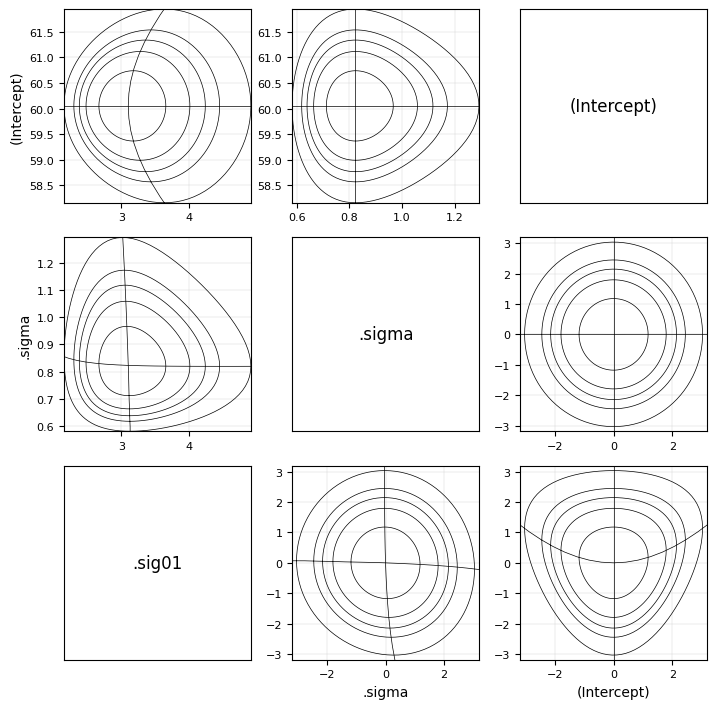

In [20]:
_ = pr04a.plot_pairs()

### 2.3.1

In [21]:
InstEval = data("InstEval", "lme4")
summary(InstEval)

      s              d        studage  lectage  service      dept
905    :   87  150    :  565  2:15406  1:20125  0:41638  12     : 9528
1325   :   85  260    :  637  4:16888  2:16297  1:31783  6      : 8097
1331   :   84  296    :  376  6:22107  3:10999           4      : 6725
1458   :   83  827    :  792  8:19020  4: 8638           9      : 6624
2088   :   92  1780   :  666           5: 6258           3      : 4749
2410   :   89  2079   :  406           6:11104           11     : 8574
(Other):72901  (Other):69979                             (Other):29124

      y
Min.   :1.000
1st Qu.:2.000
Median :3.000
Mean   :3.206
3rd Qu.:4.000
Max.   :5.000

In [22]:
summary(fm05 := lme('y ~ 1 + (1 | s) + (1 | d) + (1 | dept:service)', InstEval, REML=False))

Linear mixed model fit by maximum likelihood
Formula: y ~ 1 + (1 | s) + (1 | d) + (1 | dept:service)

        AIC         BIC       logLik   -2*log(L) df.resid
237663.2918 237709.3116 -118826.6459 237653.2918    73416

Scaled residuals:
    Min      1Q Median     3Q    Max
-2.9941 -0.7474 0.0400 0.7721 3.1124

Random effects:
 Groups       Name        Variance Std.Dev.
 s            (Intercept) 0.10541  0.3247
 d            (Intercept) 0.26256  0.5124
 dept:service (Intercept) 0.01213  0.1101
 Residual                 1.38495  1.1768
Number of obs: 73421, groups:  s, 2972; d, 1128; dept:service, 28

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   3.25521     0.02824    115.3


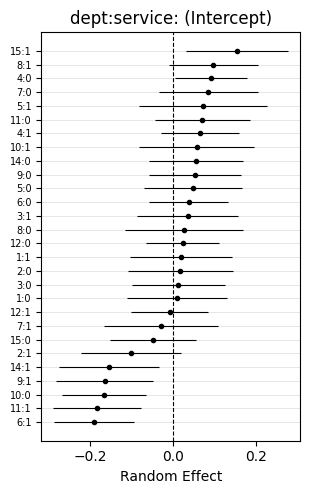

In [23]:
_ = fm05.plot_ranef(which="dept:service")

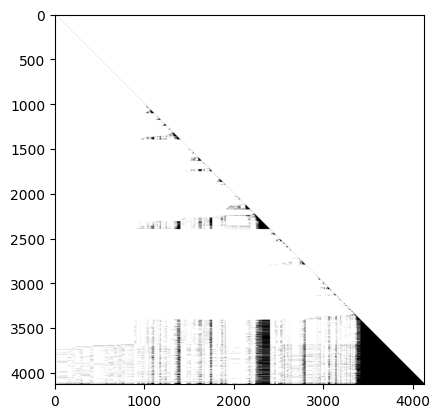

In [24]:
import matplotlib.pyplot as plt
plt.imshow(fm05.L != 0, cmap="gray_r")


In [ ]:
from hea import session_info
session_info()

Python version 3.13.11 (CPython)
Platform: arm64-darwin25.4.0
Running under: macOS 26.4.1

BLAS:   accelerate
LAPACK: accelerate

locale: C.UTF-8

time zone: CEST

hea version 0.1.3

attached packages:
[1] IPython_9.13.0    hea_0.1.3         matplotlib_3.10.9 numpy_2.4.4
[5] pandas_3.0.2      polars_1.40.1     pyarrow_24.0.0    pytest_9.0.3
[9] scipy_1.17.1

loaded via a namespace (and not attached):
 [1] PIL_12.2.0              appnope_0.1.4           argparse_1.1
 [4] asttokens_3.0.1         comm_0.2.3              csv_1.0
 [7] ctypes_1.1.0            cycler_0.12.1           dateutil_2.9.0.post0
[10] debugpy_1.8.20          decimal_1.70            decorator_5.2.1
[13] defusedxml_0.7.1        executing_2.2.1         ipaddress_1.0
[16] ipykernel_7.2.0         jedi_0.19.2             json_2.0.9
[19] jupyter_client_8.8.0    jupyter_core_5.9.1      kiwisolver_1.5.0
[22] logging_0.5.1.2         matplotlib_inline_0.2.1 packaging_26.2
[25] parso_0.8.6             platform_1.0.8          plat